# t-SNE Visualization and Anomaly Detection

## Overview

This notebook continues the dimensionality reduction work from Day 3 using the same Breast Cancer Wisconsin dataset.

The workflow is:

1. load and inspect the same 30-feature dataset,
2. standardize the numeric features,
3. recreate the 2D PCA representation as a reference,
4. apply t-SNE and inspect the effect of different perplexity values,
5. compare PCA and t-SNE on the same samples,
6. detect unusual observations with Isolation Forest,
7. inspect the anomaly count and the most unusual samples,
8. compare the idea of Isolation Forest anomalies with DBSCAN noise.

The main goal is not only to produce the plots, but to keep the interpretation correct. t-SNE is used to visualize local structure; it is not a clustering algorithm. Isolation Forest is used to detect unusual observations; the class target in this dataset is not treated as an anomaly label.

## t-SNE and Anomaly Detection

These two methods solve different problems.

**t-SNE** takes high-dimensional samples and gives each sample a low-dimensional coordinate, usually in 2D. It tries to preserve local neighborhoods, so samples that were strongly related in the original feature space tend to remain close in the embedding.

The output is only a new position such as `(t-SNE 1, t-SNE 2)`. t-SNE does not assign cluster labels, and the axes do not have direct feature meaning.

**Anomaly detection** asks a different question: which observations look unusual compared with the overall data pattern?

For this notebook I use **Isolation Forest**. Its main idea is that unusual observations are often easier to isolate with random splits, so they tend to have shorter paths through the isolation trees.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

## 2. Load the Dataset

I use the same dataset from Day 3 so the PCA and t-SNE comparison is based on the same samples and the same original 30-dimensional feature space.

The dataset also contains a diagnosis target with two classes. That target is kept separate from the feature matrix. It is used only as a visual reference when coloring plots; neither t-SNE nor Isolation Forest receives it during fitting.

The clustering notebooks from Days 1 and 2 used different datasets, so their cluster labels cannot be transferred to these samples. Cluster labels belong to specific observations. Reusing unrelated labels here would make the visualization invalid. For that reason, I use the known diagnosis group only as a color reference while keeping the t-SNE workflow itself unsupervised.

This distinction also matters for anomaly detection: a class label is not the same thing as an anomaly label. A sample can belong to either diagnosis class and still have an unusual feature profile.

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()

diagnosis = y.map(dict(enumerate(data.target_names)))

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Missing values: {X.isna().sum().sum()}")
print(f"Target classes: {[str(name) for name in data.target_names]}")

Samples: 569
Features: 30
Missing values: 0
Target classes: ['malignant', 'benign']


The dataset has 569 samples and 30 numeric features, so reducing it to two dimensions is meaningful for visualization. There are no missing values to handle before the transformations.

## 3. Standardize the Features

t-SNE builds similarities from distances in the feature space, so features with much larger numeric ranges can distort the neighborhood relationships.

I therefore use the same `StandardScaler` step from Day 3 before both PCA and t-SNE.

Isolation Forest does not depend on Euclidean distance in the same way, but I keep the same standardized representation throughout the notebook. This also makes later feature deviations easy to inspect using standardized values.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

pd.DataFrame({
    "mean_after_scaling": scaled_df.mean(),
    "std_after_scaling": scaled_df.std(ddof=0)
}).head(10)

,mean_after_scaling,std_after_scaling
mean radius,-1.373633e-16,1.0
mean texture,6.868164e-17,1.0
mean perimeter,-1.248757e-16,1.0
mean area,-2.185325e-16,1.0
mean smoothness,-8.366672e-16,1.0
mean compactness,1.873136e-16,1.0
mean concavity,4.995028e-17,1.0
mean concave points,-4.995028e-17,1.0
mean symmetry,1.748260e-16,1.0
mean fractal dimension,4.745277e-16,1.0


The scaled feature means are approximately zero and the standard deviations are one. This gives PCA and t-SNE a comparable feature space instead of letting the original measurement units dominate the result.

## 4. PCA 2D Reference

Day 3 used PCA as a linear dimensionality reduction method. I recreate the two-component representation here so the comparison with t-SNE is made under the same preprocessing and on the same samples.

PCA chooses directions that preserve as much variance as possible. The two axes are principal components, so they are weighted combinations of the original features rather than two selected original columns.

In [5]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

pca_variance = pca_2d.explained_variance_ratio_

print(f"PC1 explained variance: {pca_variance[0]:.2%}")
print(f"PC2 explained variance: {pca_variance[1]:.2%}")
print(f"Total variance shown in 2D: {pca_variance.sum():.2%}")

PC1 explained variance: 44.27%
PC2 explained variance: 18.97%
Total variance shown in 2D: 63.24%


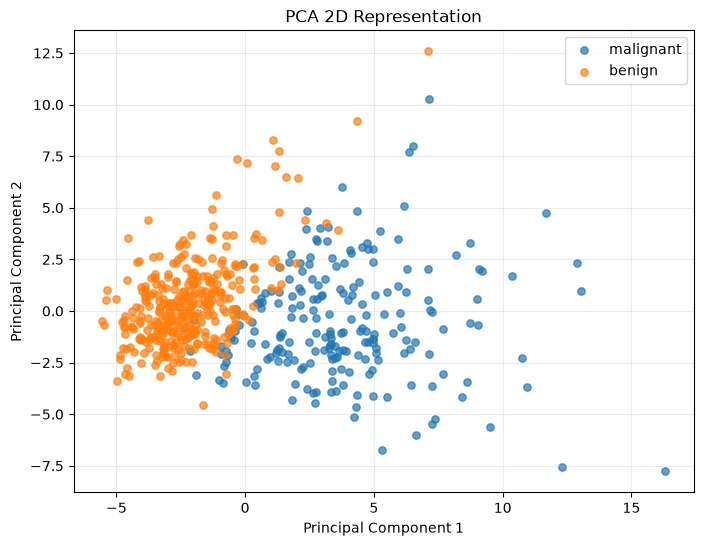

In [6]:
plt.figure(figsize=(8, 6))

for class_value, class_name in enumerate(data.target_names):
    mask = y.to_numpy() == class_value
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=28,
        alpha=0.7,
        label=class_name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Representation")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

The first two principal components keep about 63% of the standardized variance. The plot therefore gives a useful global 2D view, but it does not contain the full structure of the original 30 dimensions.

The diagnosis colors show that the two known classes have different tendencies in the PCA space, with some overlap. The target was not used to create the PCA coordinates; it is only added after the transformation to help interpret the plot.

## 5. t-SNE and the Perplexity Setting

t-SNE focuses more on **local neighborhoods** than on preserving global variance.

A useful way to read `perplexity` is as the effective neighborhood scale that t-SNE pays attention to. It is related to the number of nearby samples, but it is **not** a hard rule such as "choose exactly the nearest 30 points and ignore the rest."

Because the embedding can change when the neighborhood scale changes, I compare three reasonable values before selecting the final visualization.

I keep `random_state=42` so the stochastic part of the procedure is reproducible. This acts like a random seed; it does not make the result better by itself.

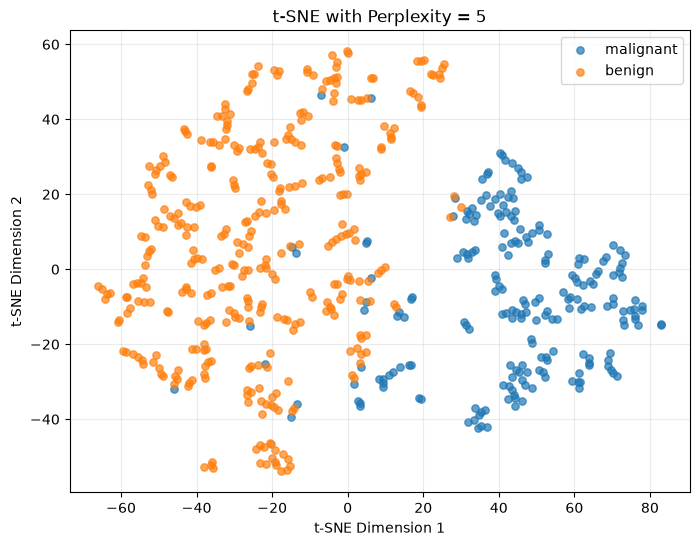

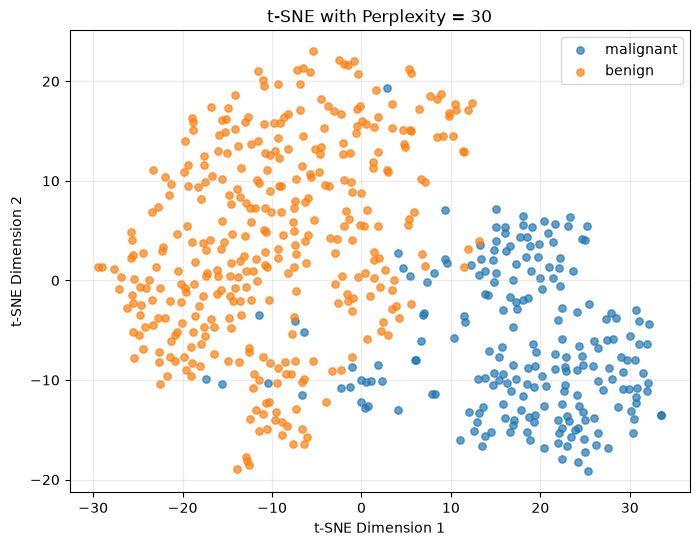

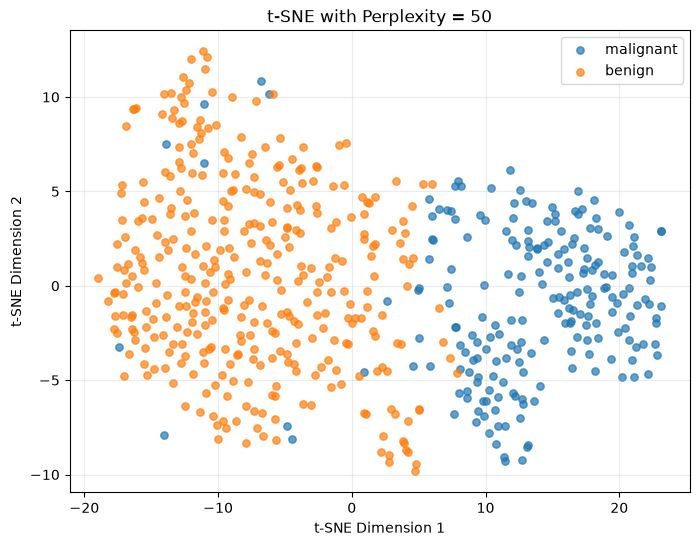

In [7]:
perplexities = [5, 30, 50]
tsne_embeddings = {}

for perplexity in perplexities:
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    tsne_embeddings[perplexity] = tsne.fit_transform(X_scaled)

for perplexity, embedding in tsne_embeddings.items():
    plt.figure(figsize=(8, 6))

    for class_value, class_name in enumerate(data.target_names):
        mask = y.to_numpy() == class_value
        plt.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=28,
            alpha=0.7,
            label=class_name
        )

    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.title(f"t-SNE with Perplexity = {perplexity}")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

The three plots show why a t-SNE visualization should not be treated as a fixed geometric map of the original feature space.

The broad local pattern is still visible, but the exact shape, spacing, and arrangement change with `perplexity`. A smaller value emphasizes a more local neighborhood scale, while larger values consider broader neighborhood relationships.

This is also why visible islands in a t-SNE plot are not enough to claim an exact number of clusters. Separation can be evidence of different local structure, but t-SNE itself does not produce cluster assignments.

## 6. Final t-SNE Representation

I use `perplexity=30` as the main visualization. It is a reasonable middle value for this dataset and avoids choosing the result only because one setting produced the most visually separated picture.

The output has shape `(569, 2)`: every original 30-dimensional sample now has two coordinates for visualization.

In [8]:
X_tsne = tsne_embeddings[30]

print(f"Original shape: {X_scaled.shape}")
print(f"t-SNE shape: {X_tsne.shape}")

Original shape: (569, 30)
t-SNE shape: (569, 2)


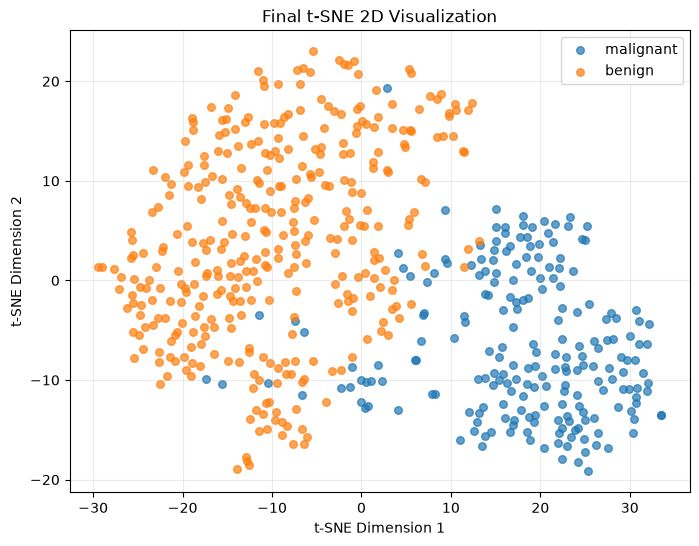

In [9]:
plt.figure(figsize=(8, 6))

for class_value, class_name in enumerate(data.target_names):
    mask = y.to_numpy() == class_value
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=30,
        alpha=0.7,
        label=class_name
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Final t-SNE 2D Visualization")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

The two t-SNE axes are only embedding coordinates. They should not be interpreted like original features, and there is no explained-variance percentage for these axes.

What matters is the relative local arrangement: samples that t-SNE considered strong neighbors in the 30-dimensional representation are encouraged to remain close in 2D.

## 7. PCA vs. t-SNE

The two methods reduce the same standardized 30-dimensional data to two dimensions, but they optimize different properties.

- **PCA** is linear and preserves directions with high variance. It is useful for compression as well as visualization.
- **t-SNE** is nonlinear and focuses on preserving local neighborhood relationships. Its main use here is visualization.
- PCA components can be examined through their loadings. t-SNE axes do not have a comparable feature interpretation.
- Large distances between t-SNE groups should not be read as exact high-dimensional distances.

The next plot places both views beside each other so the difference is easier to inspect.

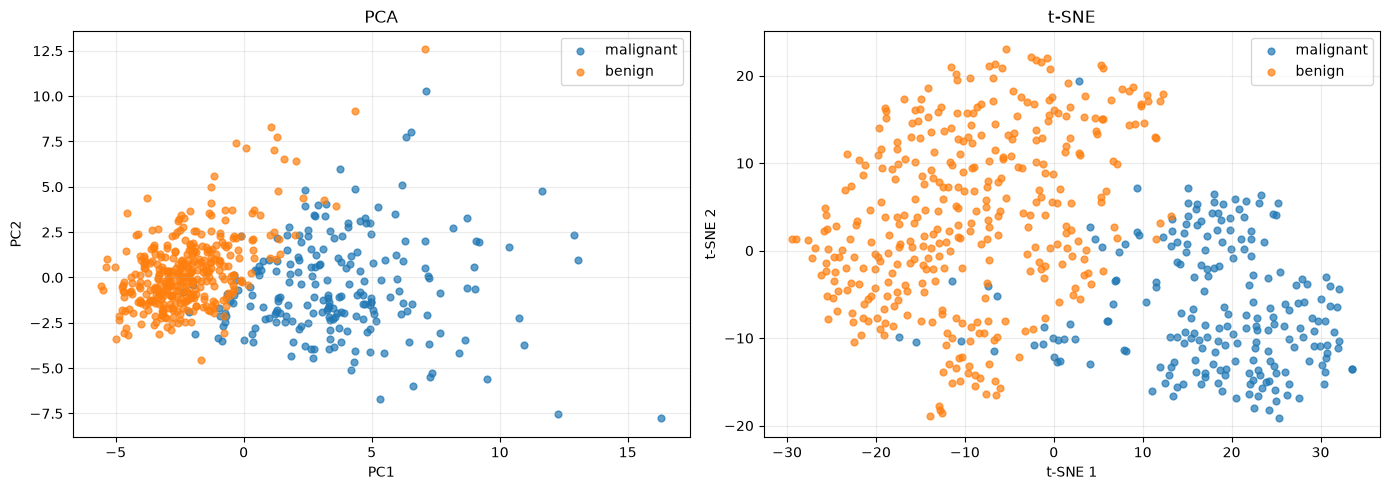

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for class_value, class_name in enumerate(data.target_names):
    mask = y.to_numpy() == class_value

    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=24,
        alpha=0.7,
        label=class_name
    )

    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=24,
        alpha=0.7,
        label=class_name
    )

axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.25)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.25)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

The comparison is consistent with the different objectives of the two methods. PCA gives a compact linear view of the major variance directions, while t-SNE produces a stronger local-neighborhood visualization.

The t-SNE view makes local group structure easier to inspect, but that does not make it a replacement for PCA. If the reduced features were needed for a downstream model or compression pipeline, PCA would be the more appropriate choice here. t-SNE is being used to inspect the data visually.

## 8. Isolation Forest for Anomaly Detection

An anomaly is an observation with an unusual feature pattern compared with the rest of the dataset. It does not automatically mean the sample is wrong, and it is not the same as one of the diagnosis classes.

Isolation Forest builds many random isolation trees. At each split it randomly chooses a feature and a split value. Samples that repeatedly become isolated after relatively few splits receive more abnormal scores.

The model is fitted only on the feature matrix.

For this lab I use:

`contamination = 0.05`

This is a working assumption that about 5% of the training observations should be treated as outliers when the decision threshold is set. It does **not** mean the algorithm independently discovered that the true anomaly rate is 5%.

In [11]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_scaled)

anomaly_labels = isolation_forest.predict(X_scaled)
decision_scores = isolation_forest.decision_function(X_scaled)

anomaly_count = np.sum(anomaly_labels == -1)
normal_count = np.sum(anomaly_labels == 1)

print(f"Normal samples: {normal_count}")
print(f"Flagged anomalies: {anomaly_count}")
print(f"Flagged fraction: {anomaly_count / len(X):.2%}")

Normal samples: 540
Flagged anomalies: 29
Flagged fraction: 5.10%


`1` means the observation is treated as an inlier and `-1` means it is flagged as an outlier.

With the 5% contamination setting, the fitted threshold flags about 5% of the training samples. The important point is that Isolation Forest first produces an abnormality score from the forest structure, then the contamination setting determines where the final normal/anomaly cutoff is placed.

In [12]:
anomaly_results = pd.DataFrame({
    "diagnosis": diagnosis,
    "isolation_label": anomaly_labels,
    "decision_score": decision_scores
}, index=X.index)

anomaly_results["status"] = anomaly_results["isolation_label"].map({
    1: "normal",
    -1: "anomaly"
})

anomaly_results.sort_values("decision_score").head(10)

,diagnosis,isolation_label,decision_score,status
212,malignant,-1,-0.153760,anomaly
461,malignant,-1,-0.151584,anomaly
122,malignant,-1,-0.133047,anomaly
108,malignant,-1,-0.112935,anomaly
152,benign,-1,-0.106699,anomaly
3,malignant,-1,-0.092113,anomaly
78,malignant,-1,-0.079786,anomaly
12,malignant,-1,-0.063560,anomaly
82,malignant,-1,-0.060853,anomaly
352,malignant,-1,-0.059865,anomaly


Lower `decision_score` values are more abnormal. The table is sorted from the samples that the fitted forest considers most unusual.

The diagnosis column is shown only for context. It is not used to decide the anomaly label, so an anomaly should not be interpreted as "malignant" and a normal point should not be interpreted as "benign." These are different concepts.

## 9. Inspect Two Flagged Samples

Simply reporting the number of anomalies is not enough. I inspect the two samples with the lowest decision scores and compare their standardized feature values with the rest of the dataset.

Because the features were standardized, an absolute value far above `1` means that measurement is several standard deviations away from the dataset mean.

In [13]:
most_unusual_indices = (
    anomaly_results
    .sort_values("decision_score")
    .head(2)
    .index
)

for sample_index in most_unusual_indices:
    sample_z = scaled_df.loc[sample_index]
    top_features = sample_z.abs().sort_values(ascending=False).head(8).index

    print(
        f"Sample {sample_index} | "
        f"Diagnosis: {diagnosis.loc[sample_index]} | "
        f"Decision score: {decision_scores[sample_index]:.4f}"
    )

    inspection = pd.DataFrame({
        "original_value": X.loc[sample_index, top_features],
        "z_score": sample_z.loc[top_features]
    })

    display(inspection)
    print()

Sample 212 | Diagnosis: malignant | Decision score: -0.1538


,original_value,z_score
area error,525.60000,10.676614
perimeter error,21.98000,9.461986
radius error,2.87300,8.906909
mean area,2499.00000,5.244841
mean perimeter,188.50000,3.976130
mean radius,28.11000,3.971288
symmetry error,0.04783,3.303954
mean concavity,0.32010,2.903973



Sample 461 | Diagnosis: malignant | Decision score: -0.1516


,original_value,z_score
area error,542.200,11.041842
perimeter error,18.650,7.813534
radius error,2.547,7.730307
worst area,4254.000,5.930172
mean area,2501.000,5.250529
worst perimeter,251.200,4.287337
worst radius,36.040,4.094189
mean perimeter,186.900,3.910226


The two most unusual samples have several measurements that are far from the dataset average at the same time. The strongest deviations include size-related measurements and error measurements with very large positive standardized values.

This gives a reasonable explanation for why they are easy to isolate across the random trees: multiple feature values place them in sparse parts of the feature space.

The result is still an anomaly flag, not a diagnosis and not proof of an error. In a real system these observations would be candidates for further inspection rather than automatically being treated as invalid data.

## 10. Visualize the Isolation Forest Result

I place the Isolation Forest labels on the t-SNE map only to inspect where the flagged samples appear visually.

The anomaly detector itself was fitted on the full 30-dimensional standardized feature matrix, **not** on the two t-SNE coordinates. This avoids turning the visualization into the input representation for anomaly detection.

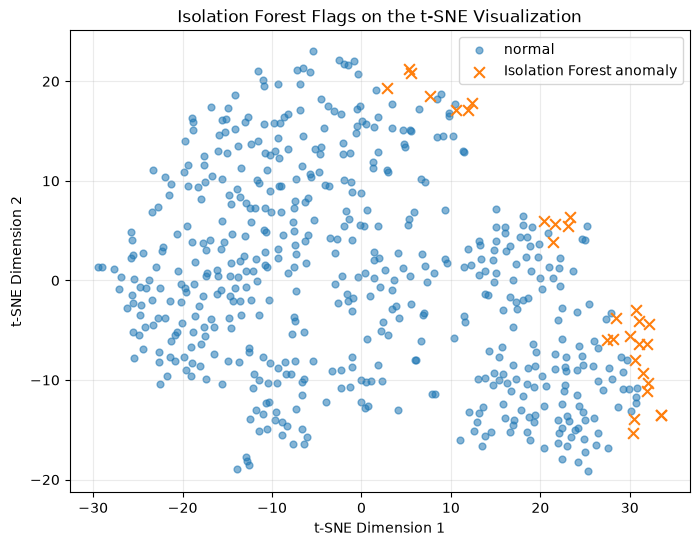

In [14]:
plt.figure(figsize=(8, 6))

normal_mask = anomaly_labels == 1
anomaly_mask = anomaly_labels == -1

plt.scatter(
    X_tsne[normal_mask, 0],
    X_tsne[normal_mask, 1],
    s=24,
    alpha=0.55,
    label="normal"
)

plt.scatter(
    X_tsne[anomaly_mask, 0],
    X_tsne[anomaly_mask, 1],
    s=60,
    marker="x",
    label="Isolation Forest anomaly"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Isolation Forest Flags on the t-SNE Visualization")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

The flagged observations are not required to form one separate visual cluster. Isolation Forest and t-SNE are solving different problems: one scores unusual observations in the original feature representation, while the other constructs a 2D neighborhood visualization.

## 11. Isolation Forest Anomaly vs. DBSCAN Noise

Both methods can identify unusual-looking observations, but the reason is different.

**DBSCAN**
- is primarily a clustering algorithm,
- builds clusters from dense connected neighborhoods using `eps` and `min_samples`,
- labels a point as `-1` when it is not reached from a dense region.

**Isolation Forest**
- is primarily an anomaly detection algorithm,
- repeatedly isolates samples using random feature splits,
- flags observations that are unusually easy to isolate.

The same sample can be marked by both methods, but `DBSCAN noise` and `Isolation Forest anomaly` are not equivalent definitions. The shared `-1` label in Scikit-learn should not be interpreted as meaning that the two algorithms made the same type of decision.

## Final Takeaway

The same 30-dimensional dataset can be inspected from several different unsupervised-learning perspectives:

- PCA reduces dimensions by preserving high-variance directions.
- t-SNE reduces dimensions for visualization by focusing on local neighborhoods.
- A t-SNE group is a visual pattern, not a cluster label produced by the algorithm.
- `perplexity` controls the effective neighborhood scale rather than an exact fixed number of neighbors.
- Isolation Forest detects unusual observations through repeated random isolation.
- `contamination` sets the decision threshold assumption; it does not create the underlying anomaly score.
- An anomaly is not automatically an error or a class label.
- DBSCAN noise and Isolation Forest anomalies can overlap, but they are produced by different objectives and mechanisms.

For this dataset, t-SNE provides a useful local view of the high-dimensional samples, while Isolation Forest flags a small set of observations with unusually extreme feature profiles for further inspection.